In [1]:
import cv2 as cv
import numpy as np

# Number of points to click
N = 6
global n
n = 0
p1 = np.empty((N,2))
p2 = np.empty((N,2))

DISPLAY_W, DISPLAY_H = 900, 650

def draw_circle(event, x, y, flags, param):
    global n
    p = param[0]
    if event == cv.EVENT_LBUTTONDOWN:
        cv.circle(param[1], (x,y), 5, (0,0,255), -1)
        p[n] = (x,y)
        n += 1

# Load images
im1 = cv.imread("/Users/sahansach/Documents/MSC/Semester 3/Computer Vision/Assignment 02/c1.jpg")
im2 = cv.imread("/Users/sahansach/Documents/MSC/Semester 3/Computer Vision/Assignment 02/c2.jpg")
im1copy = im1.copy()
im2copy = im2.copy()

# Collect points from Image 1
cv.namedWindow('Image 1', cv.WINDOW_AUTOSIZE)
param = [p1, im1copy]
cv.setMouseCallback('Image 1', draw_circle, param)
while True:
    cv.imshow("Image 1", im1copy)
    if n == N or cv.waitKey(20) & 0xFF == 27:
        break

# Collect points from Image 2
param = [p2, im2copy]
n = 0
cv.namedWindow("Image 2", cv.WINDOW_AUTOSIZE)
cv.setMouseCallback('Image 2', draw_circle, param)
while True:
    cv.imshow("Image 2", im2copy)
    if n == N or cv.waitKey(20) & 0xFF == 27:
        break

cv.destroyAllWindows()

# Compute homography
H, mask = cv.findHomography(p1, p2, cv.RANSAC)

# Warp image 1 to perspective of image 2
warped = cv.warpPerspective(im1, H, (im2.shape[1], im2.shape[0]))

cv.imshow("Warped Image", warped)
cv.waitKey(0)
cv.destroyAllWindows()
cv.waitKey(1)


-1

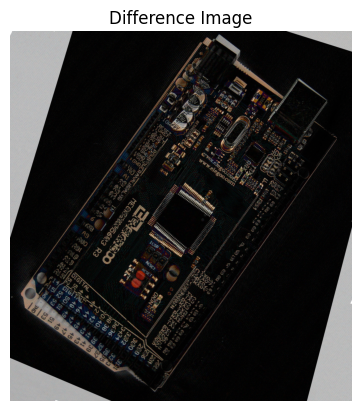

In [2]:
import matplotlib.pyplot as plt

# Difference image
diff = cv.absdiff(im2, warped)

plt.imshow(cv.cvtColor(diff, cv.COLOR_BGR2RGB))
plt.title("Difference Image")
plt.axis("off")
plt.show()


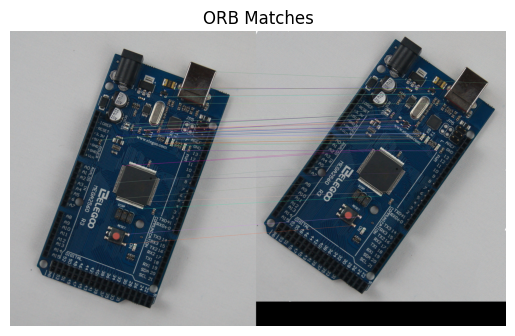

In [3]:
# Initialize ORB (SIFT requires nonfree contrib)
orb = cv.ORB_create()

kp1, des1 = orb.detectAndCompute(im1, None)
kp2, des2 = orb.detectAndCompute(im2, None)

# Match descriptors
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

# Draw matches
match_img = cv.drawMatches(im1, kp1, im2, kp2, matches[:50], None, flags=2)


plt.imshow(cv.cvtColor(match_img, cv.COLOR_BGR2RGB))
plt.title("ORB Matches")
plt.axis("off")
plt.show()
